**Import Necessary Libraries**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import re
import torch
import numpy as np
from tqdm import tqdm
import requests
import matplotlib.pyplot as plt
import json

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Text Pre-processing

In [ ]:
def clean_text(text):
    text = re.sub(r'`.*?`', '', text)
    text = re.sub(r'[\\U00010000-\\U0010ffff]', '', text)
    text = re.sub(r'[\\W]+', ' ', text)
    return text.lower().strip()

GITHUB Details - Replace GITHUB ACCESS KEY with your own Personal access token

In [ ]:
github_token = "GITHUB ACCESS KEY"
headers = {"Authorization": f"token {github_token}"}

Discussion to Issues

Progressive Comments

Title + Description + (The following Cases)

1.   All Comments
2.   1 Comment
3.   10% Comments
4.   25% Comments
5.   50% Comments
6.   75% Comments



Get the Tokenizer and Model from Hugging Face

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model = AutoModelForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2).to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Load Dataset

In [ ]:
df = pd.read_csv("DiscussionToIssue.csv")

In [ ]:
encoder = LabelEncoder()
df['IsIssueRaised'] = encoder.fit_transform(df['IsIssueRaised'])
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

Function to extract the Repositiory and Discussion number

In [ ]:
def extract_github_path(url):
    match = re.search(r'github\.com/([^?#]*)', url)
    return match.group(1) if match else None

Fetch the Comments

In [ ]:
df_shuffled['Comment'] =  None
for index,row in tqdm(df_shuffled.iterrows()):
  repo = extract_github_path(row['Issue'])
  curl = f'https://api.github.com/repos/{repo}/comments'
  repo_comment=[]
  cresponse = requests.get(curl,  headers=headers)
  if cresponse.status_code == 200:
    issueComments = cresponse.json()
    for comment in issueComments:
        repo_comment.append(comment['body'])
  df_shuffled.at[index, 'Comment'] = repo_comment

2218it [13:07,  2.82it/s]


Creating extra Columns for Progressive Checking

In [ ]:
df_shuffled['1 Comment']  = df_shuffled['Comment'].apply(lambda x: x[:1] )
df_shuffled['10% Comments']  = df_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.1)] )
df_shuffled['25% Comments']  = df_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.25)] )
df_shuffled['50% Comments']  = df_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.5)] )
df_shuffled['75% Comments']  = df_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.75)] )

In [ ]:
df_shuffled['concatenated'] = (df_shuffled['Title'] + ' ' + df_shuffled['Description'] + ' ' + df_shuffled['Comments']).apply(clean_text)
df_shuffled['concatenated_1']= (df_shuffled['Title'] + ' ' + df_shuffled['Description'] + ' ' + str(df_shuffled['1 Comment'])).apply(clean_text)
df_shuffled['concatenated_10']= (df_shuffled['Title'] + ' ' + df_shuffled['Description'] + ' ' + str(df_shuffled['10% Comments'])).apply(clean_text)
df_shuffled['concatenated_25']= (df_shuffled['Title'] + ' ' + df_shuffled['Description'] + ' ' + str(df_shuffled['25% Comments'])).apply(clean_text)
df_shuffled['concatenated_50']= (df_shuffled['Title'] + ' ' + df_shuffled['Description'] + ' ' + str(df_shuffled['50% Comments'])).apply(clean_text)
df_shuffled['concatenated_75']= (df_shuffled['Title'] + ' ' + df_shuffled['Description'] + ' ' + str(df_shuffled['75% Comments'])).apply(clean_text)

Training...

In [ ]:
inputs = tokenizer(list(df_shuffled['concatenated']), truncation=True, padding=True, return_tensors="pt", max_length=512)
labels = torch.tensor(df_shuffled['IsIssueRaised'].values)
dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
model.train()

for epoch in range(3):
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

Function for Progressive Testing

In [ ]:
def evaluate_on_column(column_name):
    print(f"\nEvaluating on {column_name}...")
    inputs = tokenizer(list(df_shuffled.loc[test_dataset.indices][column_name]),
                       truncation=True, padding=True, return_tensors="pt", max_length=512)
    labels = torch.tensor(df_shuffled.loc[test_dataset.indices]['IsIssueRaised'].values)
    dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
    loader = DataLoader(dataset, batch_size=2)

    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("Accuracy:", accuracy_score(all_labels, all_preds))
    print("Classification Report:\n", classification_report(all_labels, all_preds))
    return accuracy_score(all_labels, all_preds)

Testing with comments progressively...

In [ ]:
accuracies = []

In [ ]:
accuracies.append(evaluate_on_column('concatenated_1'))


Evaluating on concatenated_1...
Accuracy: 0.7747747747747747
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.68      0.74       206
           1       0.76      0.86      0.80       238

    accuracy                           0.77       444
   macro avg       0.78      0.77      0.77       444
weighted avg       0.78      0.77      0.77       444



In [ ]:
accuracies.append(evaluate_on_column('concatenated_10'))


Evaluating on concatenated_10...
Accuracy: 0.7522522522522522
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.92      0.78       206
           1       0.90      0.61      0.72       238

    accuracy                           0.75       444
   macro avg       0.78      0.76      0.75       444
weighted avg       0.79      0.75      0.75       444



In [ ]:
accuracies.append(evaluate_on_column('concatenated_25'))


Evaluating on concatenated_25...
Accuracy: 0.7522522522522522
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.92      0.78       206
           1       0.90      0.61      0.72       238

    accuracy                           0.75       444
   macro avg       0.78      0.76      0.75       444
weighted avg       0.79      0.75      0.75       444



In [ ]:
accuracies.append(evaluate_on_column('concatenated_50'))


Evaluating on concatenated_50...
Accuracy: 0.7635135135135135
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74       206
           1       0.77      0.79      0.78       238

    accuracy                           0.76       444
   macro avg       0.76      0.76      0.76       444
weighted avg       0.76      0.76      0.76       444



In [ ]:
accuracies.append(evaluate_on_column('concatenated_75'))


Evaluating on concatenated_75...
Accuracy: 0.7635135135135135
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74       206
           1       0.77      0.79      0.78       238

    accuracy                           0.76       444
   macro avg       0.76      0.76      0.76       444
weighted avg       0.76      0.76      0.76       444



In [ ]:
accuracies.append(evaluate_on_column('concatenated'))


Evaluating on concatenated...
Accuracy: 0.8445945945945946
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82       206
           1       0.81      0.92      0.86       238

    accuracy                           0.84       444
   macro avg       0.85      0.84      0.84       444
weighted avg       0.85      0.84      0.84       444



In [ ]:
accuracies

[0.7747747747747747,
 0.7522522522522522,
 0.7522522522522522,
 0.7635135135135135,
 0.7635135135135135,
 0.8445945945945946]

Plot the Results

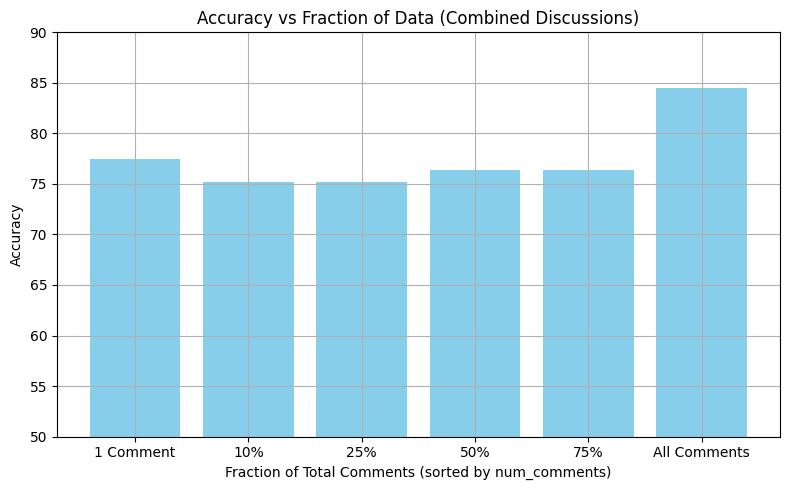

In [ ]:
x_labels = ['1 Comment', '10%', '25%', '50%', '75%', 'All Comments']
accuracies = [acc*100.0 for acc in accuracies]
plt.figure(figsize=(8, 5))
plt.bar(x_labels, accuracies, color='skyblue')
plt.xlabel("Fraction of Total Comments (sorted by num_comments)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Fraction of Data (Combined Discussions)")
plt.ylim(50, 90)
plt.grid(True)
plt.tight_layout()
plt.show()

Storing results to visualize flips in decisions

In [ ]:
results = []
for index in test_dataset.indices:
    row = df_shuffled.iloc[index]
    incremental_results = []
    base_text = row['Title'] + ' ' + row['Description']+' '
    actual_label = row['IsIssueRaised']
    comments = row['Comment']
    for i in range(0, len(comments) + 1):
        text_with_comments = base_text + ' ' + ' '.join(comments[:i+1])
        inputs = tokenizer(text_with_comments, truncation=True, padding=True, return_tensors="pt", max_length=512).to(device)

        outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'])
        pred = torch.argmax(outputs.logits, dim=1).cpu().numpy()[0]

        incremental_results.append({'link':row['Issue'], 'comments': text_with_comments,'num_comments': i, 'predicted': pred, 'actual': actual_label})

    incremental_results_df = pd.DataFrame(incremental_results)

    results.append({index: incremental_results_df})

In [ ]:
json_serializable_data = [{key: df.to_dict(orient='records')} for item in results for key, df in item.items()]
with open('output.json', 'w') as f:
    json.dump(json_serializable_data, f, indent=4)

Discusson to Issues with Description alone

Title + Description

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model = AutoModelForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2).to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
df_shuffled['concatenated'] = (df_shuffled['Title'] + ' ' + df_shuffled['Description']).apply(clean_text)
inputs = tokenizer(list(df_shuffled['concatenated']), truncation=True, padding=True, return_tensors="pt", max_length=512)
labels = torch.tensor(df_shuffled['IsIssueRaised'].values)
dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

Training...

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
model.train()

for epoch in range(3):
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

Testing...

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds))

Accuracy: 0.8040540540540541

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78       198
           1       0.82      0.83      0.82       246

    accuracy                           0.80       444
   macro avg       0.80      0.80      0.80       444
weighted avg       0.80      0.80      0.80       444



Issues to Discussion

Progressive Comments

Title + Description + (The following Cases)

1.   All Comments
2.   1 Comment
3.   10% Comments
4.   25% Comments
5.   50% Comments
6.   75% Comments



Load the dataset for Issues to Discussion

In [ ]:
df1 = pd.read_csv("IssueToDiscussion.csv")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model = AutoModelForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2).to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
encoder = LabelEncoder()
df1['ConvertedFromIssue'] = encoder.fit_transform(df1['ConvertedFromIssue'])
df1_shuffled = df1.sample(frac=1, random_state=42).reset_index(drop=True)

Download the Issue comments for progressive testing

In [ ]:
df1_shuffled['Comment'] =  None
for index,row in tqdm(df1_shuffled.iterrows()):
  repo = extract_github_path(row['Issue'])
  curl = f'https://api.github.com/repos/{repo}/comments'
  repo_comment=[]
  cresponse = requests.get(curl,  headers=headers)
  if cresponse.status_code == 200:
    issueComments = cresponse.json()
    for comment in issueComments:
        repo_comment.append(comment['body'])
  df1_shuffled.at[index, 'Comment'] = repo_comment

2010it [12:05,  2.77it/s]


Forming new columns for progressive Testing

In [ ]:
df1_shuffled['1 Comment']  = df1_shuffled['Comment'].apply(lambda x: x[:1] )
df1_shuffled['10% Comments']  = df1_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.1)] )
df1_shuffled['25% Comments']  = df1_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.25)] )
df1_shuffled['50% Comments']  = df1_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.5)] )
df1_shuffled['75% Comments']  = df1_shuffled['Comment'].apply(lambda x: x[:int(len(x)*0.75)] )

In [ ]:
df1_shuffled['concatenated'] = (df1_shuffled['Title'] + ' ' + df1_shuffled['Description'] + ' ' + df1_shuffled['Comments']).apply(clean_text)
df1_shuffled['concatenated_1']= (df1_shuffled['Title'] + ' ' + df1_shuffled['Description'] + ' ' + str(df1_shuffled['1 Comment'])).apply(clean_text)
df1_shuffled['concatenated_10']= (df1_shuffled['Title'] + ' ' + df1_shuffled['Description'] + ' ' + str(df1_shuffled['10% Comments'])).apply(clean_text)
df1_shuffled['concatenated_25']= (df1_shuffled['Title'] + ' ' + df1_shuffled['Description'] + ' ' + str(df1_shuffled['25% Comments'])).apply(clean_text)
df1_shuffled['concatenated_50']= (df1_shuffled['Title'] + ' ' + df1_shuffled['Description'] + ' ' + str(df1_shuffled['50% Comments'])).apply(clean_text)
df1_shuffled['concatenated_75']= (df1_shuffled['Title'] + ' ' + df1_shuffled['Description'] + ' ' + str(df1_shuffled['75% Comments'])).apply(clean_text)

Training ...

In [ ]:
inputs = tokenizer(list(df1_shuffled['concatenated']), truncation=True, padding=True, return_tensors="pt", max_length=512)
labels = torch.tensor(df1_shuffled['ConvertedFromIssue'].values)
dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
model.train()

for epoch in range(3):
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

Function for testing progressively

In [ ]:
def evaluate_on_column1(column_name):
    print(f"\nEvaluating on {column_name}...")
    inputs = tokenizer(list(df1_shuffled.loc[test_dataset.indices][column_name]),
                       truncation=True, padding=True, return_tensors="pt", max_length=512)
    labels = torch.tensor(df1_shuffled.loc[test_dataset.indices]['ConvertedFromIssue'].values)
    dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
    loader = DataLoader(dataset, batch_size=2)

    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("Accuracy:", accuracy_score(all_labels, all_preds))
    print("Classification Report:\n", classification_report(all_labels, all_preds))
    return accuracy_score(all_labels, all_preds)

Testing ...

In [ ]:
accuracies = []
accuracies.append(evaluate_on_column1('concatenated_1'))
accuracies.append(evaluate_on_column1('concatenated_10'))
accuracies.append(evaluate_on_column1('concatenated_25'))
accuracies.append(evaluate_on_column1('concatenated_50'))
accuracies.append(evaluate_on_column1('concatenated_75'))
accuracies.append(evaluate_on_column1('concatenated'))


Evaluating on concatenated_1...
Accuracy: 0.8656716417910447
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.98      0.88       204
           1       0.97      0.75      0.85       198

    accuracy                           0.87       402
   macro avg       0.88      0.86      0.86       402
weighted avg       0.88      0.87      0.86       402


Evaluating on concatenated_10...
Accuracy: 0.8756218905472637
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.96      0.89       204
           1       0.95      0.79      0.86       198

    accuracy                           0.88       402
   macro avg       0.89      0.87      0.87       402
weighted avg       0.89      0.88      0.87       402


Evaluating on concatenated_25...
Accuracy: 0.8756218905472637
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.

In [ ]:
accuracies

[0.8656716417910447,
 0.8756218905472637,
 0.8756218905472637,
 0.8731343283582089,
 0.8781094527363185,
 0.9154228855721394]

Plot the results

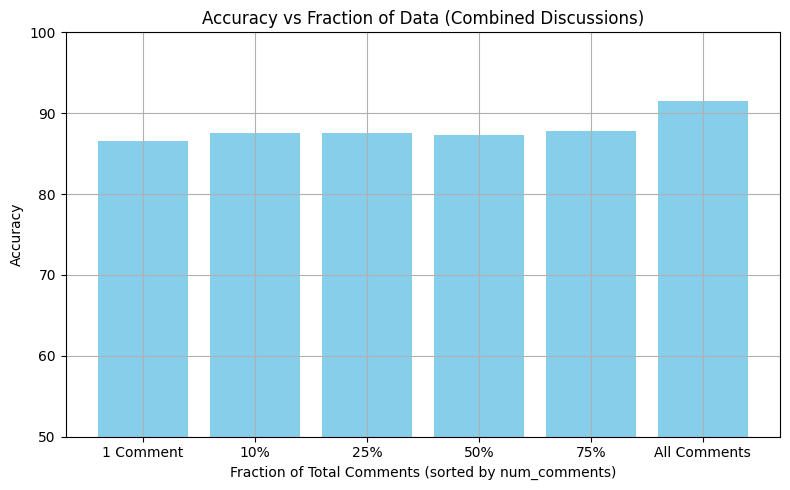

In [ ]:
x_labels = ['1 Comment', '10%', '25%', '50%', '75%', 'All Comments']
accuracies = [acc*100.0 for acc in accuracies]
plt.figure(figsize=(8, 5))
plt.bar(x_labels, accuracies, color='skyblue')
plt.xlabel("Fraction of Total Comments (sorted by num_comments)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Fraction of Data (Combined Discussions)")
plt.ylim(50, 100)
plt.grid(True)
plt.tight_layout()
plt.show()

Storing results to visualize flips in decisions

In [ ]:
results = []
for index in test_dataset.indices:
    row = df1_shuffled.iloc[index]
    incremental_results = []
    base_text = row['Title'] + ' ' + row['Description']+' '
    actual_label = row['ConvertedFromIssue']
    comments = row['Comment']
    for i in range(0, len(comments) + 1):
        text_with_comments = base_text + ' ' + ' '.join(comments[:i+1])
        inputs = tokenizer(text_with_comments, truncation=True, padding=True, return_tensors="pt", max_length=512).to(device)

        outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'])
        pred = torch.argmax(outputs.logits, dim=1).cpu().numpy()[0]

        incremental_results.append({'link':row['Issue'], 'comments': text_with_comments,'num_comments': i, 'predicted': pred, 'actual': actual_label})

    incremental_results_df = pd.DataFrame(incremental_results)

    results.append({index: incremental_results_df})

Storing the results

In [ ]:
json_serializable_data = [{key: df.to_dict(orient='records')} for item in results for key, df in item.items()]
with open('outputID.json', 'w') as f:
    json.dump(json_serializable_data, f, indent=4)

Issue to Discussion with Description alone

Title + Description



Load the dataset

In [ ]:
df1 = pd.read_csv("IssueToDiscussion.csv")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model = AutoModelForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2).to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
encoder = LabelEncoder()
df1['ConvertedFromIssue'] = encoder.fit_transform(df1['ConvertedFromIssue'])
df1_shuffled = df1.sample(frac=1, random_state=42).reset_index(drop=True)

Training ...

In [ ]:
df1_shuffled['concatenated'] = (df1_shuffled['Description']).apply(clean_text)
inputs = tokenizer(list(df1_shuffled['concatenated']), truncation=True, padding=True, return_tensors="pt", max_length=512)
labels = torch.tensor(df1_shuffled['ConvertedFromIssue'].values)
dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
model.train()

for epoch in range(3):
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

Testing ...

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds))

Accuracy: 0.8830845771144279

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87       180
           1       0.92      0.86      0.89       222

    accuracy                           0.88       402
   macro avg       0.88      0.89      0.88       402
weighted avg       0.89      0.88      0.88       402



Comments

In [ ]:
df1 = pd.read_csv("IssueToDiscussion.csv")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model = AutoModelForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2).to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
encoder = LabelEncoder()
df1['ConvertedFromIssue'] = encoder.fit_transform(df1['ConvertedFromIssue'])
df1_shuffled = df1.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df1_shuffled['concatenated'] = (df1_shuffled['Comments']).apply(clean_text)
inputs = tokenizer(list(df1_shuffled['concatenated']), truncation=True, padding=True, return_tensors="pt", max_length=512)
labels = torch.tensor(df1_shuffled['ConvertedFromIssue'].values)
dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
model.train()

for epoch in range(3):
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds))

Accuracy: 0.7711442786069652

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.91      0.79       194
           1       0.88      0.64      0.74       208

    accuracy                           0.77       402
   macro avg       0.79      0.78      0.77       402
weighted avg       0.80      0.77      0.77       402

